In [1]:
import os, json, random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import torchvision.models.segmentation as seg_models
from torchvision.datasets import STL10, OxfordIIITPet
from scipy import ndimage as ndi

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Device      : {DEVICE}")
print(f"Seed        : {SEED}")

PyTorch     : 2.10.0+cpu
Torchvision : 0.25.0+cpu
Device      : cpu
Seed        : 42


In [2]:
DATA_DIR      = "./data"
ARTIFACTS_DIR = "./artifacts"
FIGURES_DIR   = "./artifacts/figures"

for d in [DATA_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready:")
for d in [DATA_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
    print(f"  {d}/")

Directories ready:
  ./data/
  ./artifacts/
  ./artifacts/figures/


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# C1
transform_base = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# C2
transform_aug = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(64, padding=8),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.RandomRotation(degrees=15),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# C3/C4
transform_resnet = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined:")
print("  transform_base   -> 64×64, norm ±0.5")
print("  transform_aug    -> 64×64, HFlip/Crop/ColorJitter/Rotation, norm ±0.5")
print("  transform_resnet -> 224×224, ImageNet norm")

Transforms defined:
  transform_base   -> 64×64, norm ±0.5
  transform_aug    -> 64×64, HFlip/Crop/ColorJitter/Rotation, norm ±0.5
  transform_resnet -> 224×224, ImageNet norm


In [4]:
NUM_CLASSES = 10
BATCH_SIZE  = 64

# Train split: 5 000 images (500 / class)
# Test  split: 8 000 images

full_train_base = STL10(root=DATA_DIR, split='train', download=True,  transform=transform_base)
full_train_aug  = STL10(root=DATA_DIR, split='train', download=False, transform=transform_aug)
full_train_rn   = STL10(root=DATA_DIR, split='train', download=False, transform=transform_resnet)

test_base   = STL10(root=DATA_DIR, split='test', download=False, transform=transform_base)
test_resnet = STL10(root=DATA_DIR, split='test', download=False, transform=transform_resnet)

# Fixed 80/20 split
n_train = len(full_train_base)   # 5 000
n_val   = int(0.2 * n_train)     # 1 000
n_tr    = n_train - n_val        # 4 000

rng        = np.random.default_rng(SEED)
all_idx    = rng.permutation(n_train).tolist()
train_idx  = all_idx[:n_tr]
val_idx    = all_idx[n_tr:]

STL10_CLASSES = full_train_base.classes
print(f"STL10 | train_subset: {len(train_idx)}, val_subset: {len(val_idx)}, test: {len(test_base)}")
print(f"Classes ({NUM_CLASSES}): {STL10_CLASSES}")

STL10 | train_subset: 4000, val_subset: 1000, test: 8000
Classes (10): ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
def make_loaders(train_ds, val_ds, test_ds, t_idx, v_idx, bs=64, num_workers=0):
    tr_loader = DataLoader(Subset(train_ds, t_idx), batch_size=bs,
                           shuffle=True,  num_workers=num_workers, pin_memory=False)
    vl_loader = DataLoader(Subset(val_ds,   v_idx), batch_size=bs,
                           shuffle=False, num_workers=num_workers, pin_memory=False)
    te_loader = DataLoader(test_ds,                 batch_size=bs,
                           shuffle=False, num_workers=num_workers, pin_memory=False)
    return tr_loader, vl_loader, te_loader

# C1 / C2
loader_train_base, loader_val_base, loader_test_base = make_loaders(
    full_train_base, full_train_base, test_base, train_idx, val_idx)
loader_train_aug, _, _ = make_loaders(
    full_train_aug, full_train_base, test_base, train_idx, val_idx)

# C3 / C4
loader_train_rn, loader_val_rn, loader_test_rn = make_loaders(
    full_train_rn, full_train_rn, test_resnet, train_idx, val_idx)

print("DataLoaders created.")
print(f"  Batches per epoch (train): {len(loader_train_base)}")
print(f"  Batches per epoch (val)  : {len(loader_val_base)}")

DataLoaders created.
  Batches per epoch (train): 63
  Batches per epoch (val)  : 16


In [6]:
x_batch, y_batch = next(iter(loader_train_base))
print("Sanity check")
print(f"x.shape : {x_batch.shape}  (N, C, H, W)")
print(f"y.shape : {y_batch.shape}")
print(f"x range : [{x_batch.min():.3f}, {x_batch.max():.3f}]")
print(f"Classes in batch: {torch.bincount(y_batch).tolist()}")

Sanity check
x.shape : torch.Size([64, 3, 64, 64])  (N, C, H, W)
y.shape : torch.Size([64])
x range : [-1.000, 1.000]
Classes in batch: [9, 7, 6, 6, 2, 6, 8, 7, 6, 7]


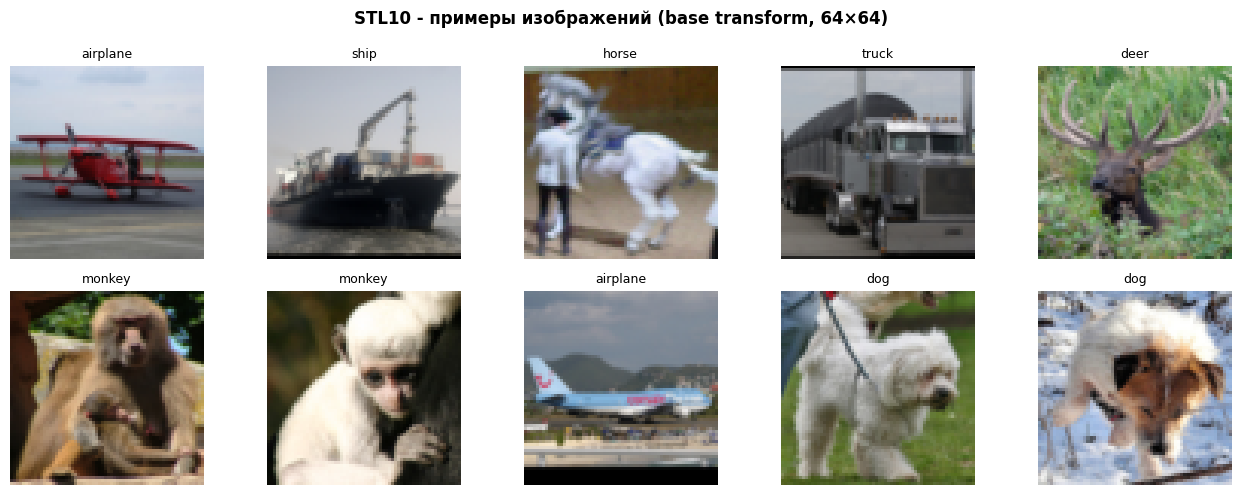

Saved stl10_samples.png


In [7]:
def denorm(t, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    t = t.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.permute(1, 2, 0).clamp(0, 1).numpy()

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(x_batch[i]))
    ax.set_title(STL10_CLASSES[y_batch[i].item()], fontsize=9)
    ax.axis('off')
fig.suptitle("STL10 - примеры изображений (base transform, 64×64)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stl10_samples.png"), dpi=100, bbox_inches='tight')
plt.show()
print("Saved stl10_samples.png")

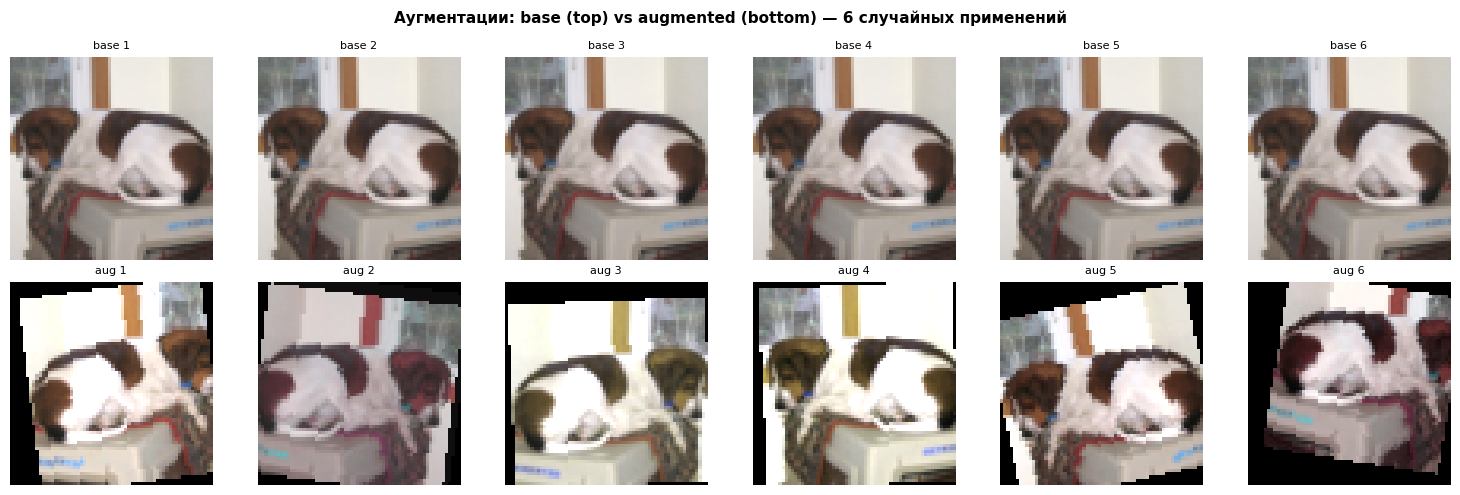

Saved augmentations_preview.png


In [8]:
# STL10.data is stored as (N, 3, 96, 96) uint8
raw_arr = full_train_base.data[train_idx[0]]          # (3, 96, 96)
pil_img = Image.fromarray(raw_arr.transpose(1, 2, 0)) # (96, 96, 3)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle("Аугментации: base (top) vs augmented (bottom) — 6 случайных применений",
             fontsize=11, fontweight='bold')

for i in range(6):
    img_b = denorm(transform_base(pil_img))
    img_a = denorm(transform_aug(pil_img))

    axes[0, i].imshow(img_b); axes[0, i].axis('off')
    axes[0, i].set_title(f"base {i+1}", fontsize=8)

    axes[1, i].imshow(img_a); axes[1, i].axis('off')
    axes[1, i].set_title(f"aug {i+1}", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "augmentations_preview.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved augmentations_preview.png")

In [9]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 64 → 32
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 2: 32 → 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 3: 16 → 8
            nn.Conv2d(64, 128,kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


# Quick shape check
_dummy = torch.zeros(2, 3, 64, 64)
_cnn   = SimpleCNN(10)
assert _cnn(_dummy).shape == (2, 10), "Shape mismatch"
n_params = sum(p.numel() for p in _cnn.parameters() if p.requires_grad)
print(f"SimpleCNN OK — output: {_cnn(_dummy).shape}")
print(f"Trainable parameters: {n_params:,}")

SimpleCNN OK — output: torch.Size([2, 10])
Trainable parameters: 2,193,674


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n


def run_experiment(model, loader_train, loader_val, *,
                   epochs=20, lr=1e-3, weight_decay=1e-4,
                   device=DEVICE, exp_id='EXP', verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)

    history = {k: [] for k in ('train_loss', 'val_loss', 'train_acc', 'val_acc')}
    best_val_acc = 0.0
    best_state   = None
    best_epoch   = 0

    model.to(device)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, loader_train, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(model, loader_val, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_epoch   = epoch
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == epochs):
            print(f"[{exp_id}] ep {epoch:>3d}/{epochs} | "
                  f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
                  f"val loss={vl_loss:.4f} acc={vl_acc:.4f}"
                  + (" best" if epoch == best_epoch else ""))

    model.load_state_dict(best_state)
    if verbose:
        print(f"[{exp_id}] Best val acc = {best_val_acc:.4f} @ epoch {best_epoch}\n")
    return model, history, best_val_acc, best_epoch


print("Training utilities ready.")

Training utilities ready.


In [ ]:
print("C1: SimpleCNN - base transforms (no augmentation)")

model_c1 = SimpleCNN(num_classes=NUM_CLASSES)
model_c1, hist_c1, best_val_c1, best_ep_c1 = run_experiment(
    model_c1, loader_train_base, loader_val_base,
    epochs=20, lr=1e-3, weight_decay=1e-4, exp_id='C1'
)
print(f"C1  best_val_acc = {best_val_c1:.4f}")

C1: SimpleCNN - base transforms (no augmentation)
[C1] ep   1/20 | train loss=2.2092 acc=0.2597 | val loss=1.6980 acc=0.3730 best
[C1] ep   5/20 | train loss=1.3896 acc=0.4718 | val loss=1.3946 acc=0.4850


In [ ]:
print("C2: SimpleCNN - augmented training (same architecture as C1)")

model_c2 = SimpleCNN(num_classes=NUM_CLASSES)
model_c2, hist_c2, best_val_c2, best_ep_c2 = run_experiment(
    model_c2,
    loader_train_aug,   # augmented training
    loader_val_base,    # val always uses base (no aug for evaluation)
    epochs=20, lr=1e-3, weight_decay=1e-4, exp_id='C2'
)
print(f"C2  best_val_acc = {best_val_c2:.4f}")
print(f"Δ vs C1: {best_val_c2 - best_val_c1:+.4f}")

In [ ]:
def make_resnet18_head_only(num_classes: int = 10):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in model.parameters():      # freeze all
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)  # new head, trainable
    n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {n_tr:,} / {n_tot:,} params ({100*n_tr/n_tot:.1f}%)")
    return model

print("C3: ResNet18 - head-only (backbone frozen)")

model_c3 = make_resnet18_head_only(NUM_CLASSES)
model_c3, hist_c3, best_val_c3, best_ep_c3 = run_experiment(
    model_c3, loader_train_rn, loader_val_rn,
    epochs=10, lr=1e-3, weight_decay=1e-4, exp_id='C3'
)
print(f"C3  best_val_acc = {best_val_c3:.4f}")

In [ ]:
def make_resnet18_finetune(num_classes: int = 10):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in model.parameters():           # freeze all
        p.requires_grad = False
    for p in model.layer4.parameters():    # unfreeze layer4
        p.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)  # new head, trainable
    n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {n_tr:,} / {n_tot:,} params ({100*n_tr/n_tot:.1f}%)")
    return model

print("C4: ResNet18 - partial fine-tuning (layer4 + fc)")

model_c4 = make_resnet18_finetune(NUM_CLASSES)
model_c4, hist_c4, best_val_c4, best_ep_c4 = run_experiment(
    model_c4, loader_train_rn, loader_val_rn,
    epochs=10, lr=5e-4, weight_decay=1e-4, exp_id='C4'
)
print(f"C4  best_val_acc = {best_val_c4:.4f}")

In [ ]:
exp_ids  = ['C1', 'C2', 'C3', 'C4']
val_accs = [best_val_c1, best_val_c2, best_val_c3, best_val_c4]
colors   = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759']
xlabels  = [
    'C1\nSimpleCNN\n(no aug)',
    'C2\nSimpleCNN\n(aug)',
    'C3\nResNet18\n(head-only)',
    'C4\nResNet18\n(finetune)',
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(exp_ids, [a * 100 for a in val_accs], color=colors, width=0.5, edgecolor='white', linewidth=1.2)
for bar, acc in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{acc:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(exp_ids)))
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel("Best Val Accuracy (%)", fontsize=12)
ax.set_ylim(0, max(val_accs) * 100 + 10)
ax.set_title("C1-C4: Сравнение лучшей val accuracy", fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved classification_compare.png")
print()
for eid, acc in zip(exp_ids, val_accs):
    marker = " ← BEST" if acc == max(val_accs) else ""
    print(f"  {eid}: best_val_acc = {acc:.4f}{marker}")

In [ ]:
best_idx  = int(np.argmax(val_accs))
best_name = exp_ids[best_idx]
best_acc  = val_accs[best_idx]
print(f"Best model: {best_name}  (val_acc = {best_acc:.4f})")

_map = {
    'C1': (model_c1, hist_c1, loader_test_base, 'SimpleCNN',           1e-3),
    'C2': (model_c2, hist_c2, loader_test_base, 'SimpleCNN',           1e-3),
    'C3': (model_c3, hist_c3, loader_test_rn,   'ResNet18-head-only',  1e-3),
    'C4': (model_c4, hist_c4, loader_test_rn,   'ResNet18-finetune',   5e-4),
}
best_model, best_hist, best_test_loader, best_arch, best_lr = _map[best_name]

# Learning curves
ep_range = range(1, len(best_hist['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ep_range, best_hist['train_loss'], label='Train Loss', color='steelblue',  linewidth=1.8)
ax1.plot(ep_range, best_hist['val_loss'],   label='Val Loss',   color='tomato',     linewidth=1.8)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'{best_name}: Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_range, best_hist['train_acc'], label='Train Acc', color='steelblue',  linewidth=1.8)
ax2.plot(ep_range, best_hist['val_acc'],   label='Val Acc',   color='tomato',     linewidth=1.8)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'{best_name}: Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'Лучший прогон: {best_name} — кривые обучения', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "classification_curves_best.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved classification_curves_best.png")

In [ ]:
criterion_eval = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, best_test_loader, criterion_eval, DEVICE)
print(f"FINAL TEST RESULT  —  {best_name}")
print(f"  test_loss = {test_loss:.4f}")
print(f"  test_acc  = {test_acc:.4f}")

In [ ]:
# best_classifier.pt
torch.save(best_model.state_dict(),
           os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))

# best_classifier_config.json
config = {
    "experiment_id"  : best_name,
    "architecture"   : best_arch,
    "dataset"        : "STL10",
    "num_classes"    : NUM_CLASSES,
    "seed"           : SEED,
    "input_size"     : 64 if best_name in ('C1', 'C2') else 224,
    "normalize_mean" : [0.5, 0.5, 0.5] if best_name in ('C1', 'C2') else IMAGENET_MEAN,
    "normalize_std"  : [0.5, 0.5, 0.5] if best_name in ('C1', 'C2') else IMAGENET_STD,
    "augmentation"   : best_name == 'C2',
    "frozen_layers"  : ("all backbone" if best_name == 'C3'
                        else "layer1-3" if best_name == 'C4'
                        else "none"),
    "batch_size"     : BATCH_SIZE,
    "epochs_trained" : len(best_hist['train_acc']),
    "optimizer"      : "Adam",
    "lr"             : best_lr,
    "weight_decay"   : 1e-4,
    "scheduler"      : "CosineAnnealingLR",
    "best_val_acc"   : round(best_acc, 6),
    "test_acc"       : round(test_acc, 6),
}
with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), 'w') as f:
    json.dump(config, f, indent=2)

print("Saved: artifacts/best_classifier.pt")
print("Saved: artifacts/best_classifier_config.json")
print(json.dumps(config, indent=2))

In [ ]:
IMAGENET_MEAN_SEG = [0.485, 0.456, 0.406]
IMAGENET_STD_SEG  = [0.229, 0.224, 0.225]

SEG_SIZE = 520

transform_seg_img = T.Compose([
    T.Resize((SEG_SIZE, SEG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN_SEG, std=IMAGENET_STD_SEG),
])
transform_seg_mask = T.Resize((SEG_SIZE, SEG_SIZE),
                               interpolation=T.InterpolationMode.NEAREST)


class OxfordPetSeg(torch.utils.data.Dataset):

    def __init__(self, root, split='test', download=True):
        self.ds = OxfordIIITPet(
            root=root, split=split, target_types='segmentation',
            download=download, transform=None, target_transform=None
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]                      # PIL images
        img_t    = transform_seg_img(img)             # Tensor C H W
        mask_pil = transform_seg_mask(mask)           # PIL resized nearest
        mask_arr = np.array(mask_pil, dtype=np.int64) # H W, values {1,2,3}
        return img_t, mask_arr


pet_ds = OxfordPetSeg(root=DATA_DIR, split='test', download=True)
print(f"OxfordIIITPet (test split): {len(pet_ds)} images")

# Sanity check
img_t0, mask0 = pet_ds[0]
print(f"Image tensor : {img_t0.shape}")
print(f"Mask array   : {mask0.shape}, dtype={mask0.dtype}")
print(f"Mask values  : {np.unique(mask0)} (1=pet, 2=bg, 3=border)")

In [ ]:
def denorm_imagenet(t):
    t = t.clone()
    for c, (m, s) in enumerate(zip(IMAGENET_MEAN_SEG, IMAGENET_STD_SEG)):
        t[c] = t[c] * s + m
    return t.permute(1, 2, 0).clamp(0, 1).numpy()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col in range(4):
    img_t_i, mask_i = pet_ds[col]
    axes[0, col].imshow(denorm_imagenet(img_t_i))
    axes[0, col].set_title(f"Image [{col}]", fontsize=9); axes[0, col].axis('off')
    im = axes[1, col].imshow(mask_i, cmap='tab10', vmin=0, vmax=3)
    axes[1, col].set_title("Mask (1=pet 2=bg 3=border)", fontsize=8); axes[1, col].axis('off')

plt.suptitle("OxfordIIITPet — sanity check данных для сегментации", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pet_data_samples.png"), dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Pascal VOC class indices
CAT_CLASS          = 8
DOG_CLASS          = 12
FOREGROUND_CLASSES = [CAT_CLASS, DOG_CLASS]

seg_model = seg_models.fcn_resnet50(
    weights=seg_models.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
)
seg_model.eval()
seg_model.to(DEVICE)

print("FCN_ResNet50 loaded (pretrained COCO_WITH_VOC_LABELS_V1)")
print(f"Foreground classes: cat={CAT_CLASS}, dog={DOG_CLASS}")

In [ ]:
def predict_fg_v1(model, img_tensor, fg_classes=FOREGROUND_CLASSES, device=DEVICE):
    inp = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(inp)['out']
    pred_cls = logits.argmax(dim=1).squeeze(0).cpu().numpy()
    return np.isin(pred_cls, fg_classes).astype(np.uint8)


def compute_seg_metrics(pred_fg: np.ndarray, gt_mask: np.ndarray, fg_value: int = 1):
    gt_fg   = (gt_mask == fg_value)
    pred_fg = pred_fg.astype(bool)
    inter   = (gt_fg & pred_fg).sum()
    union   = (gt_fg | pred_fg).sum()
    iou     = inter / (union + 1e-8)
    prec    = inter / (pred_fg.sum() + 1e-8)
    rec     = inter / (gt_fg.sum() + 1e-8)
    return float(iou), float(prec), float(rec)


print("Seg utilities ready.")

In [ ]:
N_EVAL = 150
rng_eval  = np.random.default_rng(SEED)
eval_idxs = rng_eval.choice(len(pet_ds), size=N_EVAL, replace=False).tolist()

metrics_v1 = []
for idx in eval_idxs:
    img_t, mask_arr = pet_ds[idx]
    pred_fg = predict_fg_v1(seg_model, img_t)
    iou, prec, rec  = compute_seg_metrics(pred_fg, mask_arr)
    metrics_v1.append(dict(iou=iou, precision=prec, recall=rec))

mv1 = {k: float(np.mean([m[k] for m in metrics_v1])) for k in ('iou', 'precision', 'recall')}
print(f"V1 metrics (mean, N={N_EVAL} images):")
print(f"  mean_iou        = {mv1['iou']:.4f}")
print(f"  pixel_precision = {mv1['precision']:.4f}")
print(f"  pixel_recall    = {mv1['recall']:.4f}")

In [ ]:
def remove_small_components(binary_mask: np.ndarray, min_size: int = 1000) -> np.ndarray:
    labeled, n_feat = ndi.label(binary_mask)
    if n_feat == 0:
        return binary_mask.copy()
    comp_sizes = ndi.sum(binary_mask, labeled, range(1, n_feat + 1))
    keep = np.array(comp_sizes) >= min_size
    clean = keep[labeled - 1]
    clean[labeled == 0] = False
    return clean.astype(np.uint8)


def predict_fg_v2(model, img_tensor, fg_classes=FOREGROUND_CLASSES,
                  min_size=1000, device=DEVICE):
    fg_v1 = predict_fg_v1(model, img_tensor, fg_classes, device)
    return remove_small_components(fg_v1, min_size=min_size)


# Evaluate V2
metrics_v2 = []
for idx in eval_idxs:
    img_t, mask_arr = pet_ds[idx]
    pred_fg = predict_fg_v2(seg_model, img_t)
    iou, prec, rec  = compute_seg_metrics(pred_fg, mask_arr)
    metrics_v2.append(dict(iou=iou, precision=prec, recall=rec))

mv2 = {k: float(np.mean([m[k] for m in metrics_v2])) for k in ('iou', 'precision', 'recall')}
print(f"V2 metrics (mean, N={N_EVAL} images):")
print(f"  mean_iou        = {mv2['iou']:.4f}")
print(f"  pixel_precision = {mv2['precision']:.4f}")
print(f"  pixel_recall    = {mv2['recall']:.4f}")
print()
print(f"Δ IoU (V2 - V1)       = {mv2['iou']-mv1['iou']:+.4f}")
print(f"Δ Precision (V2 - V1) = {mv2['precision']-mv1['precision']:+.4f}")
print(f"Δ Recall    (V2 - V1) = {mv2['recall']-mv1['recall']:+.4f}")

In [ ]:
def overlay_mask(img_np, mask, alpha=0.45, color=(0.2, 0.85, 0.2)):
    out = img_np.copy()
    for c, cv in enumerate(color):
        out[:, :, c] = np.where(mask, alpha * cv + (1 - alpha) * img_np[:, :, c],
                                img_np[:, :, c])
    return np.clip(out, 0, 1)

VIS_N = 4
vis_idxs = eval_idxs[:VIS_N]

fig, axes = plt.subplots(VIS_N, 4, figsize=(16, VIS_N * 4))
col_titles = ['Image + GT overlay', 'GT mask\n(1=pet)', 'V1 prediction', 'V2 prediction\n(cleaned)']
for c, ct in enumerate(col_titles):
    axes[0, c].set_title(ct, fontsize=10, fontweight='bold')

for row, idx in enumerate(vis_idxs):
    img_t, mask_arr = pet_ds[idx]
    img_np  = denorm_imagenet(img_t)
    gt_fg   = (mask_arr == 1).astype(np.uint8)
    pred_v1 = predict_fg_v1(seg_model, img_t)
    pred_v2 = predict_fg_v2(seg_model, img_t)

    axes[row, 0].imshow(overlay_mask(img_np, gt_fg, color=(0.1, 0.5, 1.0)))
    axes[row, 1].imshow(gt_fg,   cmap='Greens', vmin=0, vmax=1)
    axes[row, 2].imshow(overlay_mask(img_np, pred_v1))
    axes[row, 3].imshow(overlay_mask(img_np, pred_v2))
    for ax in axes[row]: ax.axis('off')

plt.suptitle("Segmentation results: GT | V1 (base) | V2 (small-CC removed)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_examples.png"), dpi=100, bbox_inches='tight')
plt.show()
print("Saved segmentation_examples.png")

In [ ]:
metric_keys   = ['iou', 'precision', 'recall']
metric_labels = ['mean_IoU', 'pixel_precision', 'pixel_recall']
colors_v12    = ['#4e79a7', '#f28e2b']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (mkey, mlabel) in enumerate(zip(metric_keys, metric_labels)):
    vals = [mv1[mkey], mv2[mkey]]
    bars = axes[i].bar(['V1\n(base)', 'V2\n(cleaned)'], vals,
                       color=colors_v12, width=0.5, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                     f"{v:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[i].set_title(mlabel, fontsize=11)
    axes[i].set_ylim(0, min(1.0, max(vals) + 0.12))
    axes[i].grid(True, axis='y', alpha=0.3)

plt.suptitle("V1 vs V2 — Segmentation Metrics (OxfordIIITPet, FCN_ResNet50)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_metrics.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved segmentation_metrics.png")

In [ ]:
rows = [
    dict(
        experiment_id='C1', task='classification', dataset='STL10', seed=SEED,
        model_summary='SimpleCNN 3conv+2fc, no aug',
        optimizer='Adam', lr=1e-3, epochs_trained=len(hist_c1['train_acc']),
        best_val_accuracy=round(best_val_c1, 6),
        test_accuracy=round(test_acc, 6) if best_name == 'C1' else '',
        precision='', recall='', mean_iou='',
        notes='Baseline. Base transforms (64×64, norm ±0.5).',
    ),
    dict(
        experiment_id='C2', task='classification', dataset='STL10', seed=SEED,
        model_summary='SimpleCNN 3conv+2fc, with aug',
        optimizer='Adam', lr=1e-3, epochs_trained=len(hist_c2['train_acc']),
        best_val_accuracy=round(best_val_c2, 6),
        test_accuracy=round(test_acc, 6) if best_name == 'C2' else '',
        precision='', recall='', mean_iou='',
        notes='Same arch as C1. Aug: RandomHFlip, RandomCrop(pad=8), ColorJitter, RandomRotation(15).',
    ),
    dict(
        experiment_id='C3', task='classification', dataset='STL10', seed=SEED,
        model_summary='ResNet18-pretrained, head-only (backbone frozen)',
        optimizer='Adam', lr=1e-3, epochs_trained=len(hist_c3['train_acc']),
        best_val_accuracy=round(best_val_c3, 6),
        test_accuracy=round(test_acc, 6) if best_name == 'C3' else '',
        precision='', recall='', mean_iou='',
        notes='ResNet18 IMAGENET1K_V1. All backbone frozen; only fc trained (512→10).',
    ),
    dict(
        experiment_id='C4', task='classification', dataset='STL10', seed=SEED,
        model_summary='ResNet18-pretrained, layer4+fc fine-tuned',
        optimizer='Adam', lr=5e-4, epochs_trained=len(hist_c4['train_acc']),
        best_val_accuracy=round(best_val_c4, 6),
        test_accuracy=round(test_acc, 6) if best_name == 'C4' else '',
        precision='', recall='', mean_iou='',
        notes='ResNet18 IMAGENET1K_V1. layer4+fc unfrozen, lower lr=5e-4.',
    ),
    dict(
        experiment_id='V1', task='segmentation', dataset='OxfordIIITPet', seed=SEED,
        model_summary='FCN_ResNet50 COCO_WITH_VOC_LABELS_V1; argmax→{8,12}→fg',
        optimizer='N/A (inference only)', lr='', epochs_trained=0,
        best_val_accuracy='', test_accuracy='',
        precision=round(mv1['precision'], 6),
        recall=round(mv1['recall'], 6),
        mean_iou=round(mv1['iou'], 6),
        notes=f'No postprocessing. Evaluated on {N_EVAL} images from test split.',
    ),
    dict(
        experiment_id='V2', task='segmentation', dataset='OxfordIIITPet', seed=SEED,
        model_summary='FCN_ResNet50 + remove CC<1000px (scipy.ndimage)',
        optimizer='N/A (inference only)', lr='', epochs_trained=0,
        best_val_accuracy='', test_accuracy='',
        precision=round(mv2['precision'], 6),
        recall=round(mv2['recall'], 6),
        mean_iou=round(mv2['iou'], 6),
        notes=f'V1 + connected-component filter (min_size=1000 px). N={N_EVAL}.',
    ),
]

df_runs = pd.DataFrame(rows)
df_runs.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)
print("Saved artifacts/runs.csv")
print()
cols_show = ['experiment_id','task','best_val_accuracy','test_accuracy','precision','recall','mean_iou']
print(df_runs[cols_show].to_string(index=False))